# 0. Setup

In [1]:
import kagglehub
data_path = kagglehub.dataset_download('danielagluj/sleep-30s-spectrograms-from-dodh-dataset')

100%|██████████| 463M/463M [00:06<00:00, 76.2MB/s]

Extracting files...


In [2]:
import shutil
import os

src = data_path
dst = "/content/data"
if not os.path.exists(dst):
    shutil.copytree(src, dst)

In [3]:
!pip install -q segmentation-models-pytorch albumentations opencv-python scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from tqdm import tqdm
import time
import random
seed = 11
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


# 1. EDA

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

TRAIN_PATH = '/content/data/sleep_spectrogram_dataset'
TEST_PATH = '/content/data/test_set_unseen_sub015'

CLASSES = ['W', 'N1', 'N2', 'N3', 'REM']

TRAIN_PATH, TEST_PATH, CLASSES

('/content/data/sleep_spectrogram_dataset',
 '/content/data/test_set_unseen_sub015',
 ['W', 'N1', 'N2', 'N3', 'REM'])

In [6]:
def get_dataset_stats(data_path, classes):
    stats = {
        'class': [],
        'num_images': [],
        'patient_ids': []
    }

    for cls in classes:
        class_path = os.path.join(data_path, cls)
        if not os.path.exists(class_path):
            print(f"Warning: {class_path} does not exist")
            continue

        files = [f for f in os.listdir(class_path) if f.endswith('.png')]

        patient_ids = set()
        for f in files:
            patient_id = f.split('_')[0]
            patient_ids.add(patient_id)

        stats['class'].append(cls)
        stats['num_images'].append(len(files))
        stats['patient_ids'].append(patient_ids)

    df = pd.DataFrame({
        'class': stats['class'],
        'num_images': stats['num_images'],
        'num_patients': [len(pids) for pids in stats['patient_ids']]
    })

    return df, stats['patient_ids']

train_stats, train_patient_ids = get_dataset_stats(TRAIN_PATH, CLASSES)
print(train_stats)
print(f"\nTotal training images: {train_stats['num_images'].sum()}")
print(f"Total unique patients in train: {len(set.union(*train_patient_ids))}")

test_stats, test_patient_ids = get_dataset_stats(TEST_PATH, CLASSES)
print(test_stats)
print(f"\nTotal test images: {test_stats['num_images'].sum()}")
print(f"Total unique patients in test: {len(set.union(*test_patient_ids))}")

train_patients = set.union(*train_patient_ids)
test_patients = set.union(*test_patient_ids)
overlap = train_patients.intersection(test_patients)
print(f"\nPatient overlap between train and test: {overlap}")
if len(overlap) == 0:
    print("No patient leakage detected")
else:
    print("Patient leakage")

  class  num_images  num_patients
0     W        1008             5
1    N1         317             5
2    N2        2047             5
3    N3         523             5
4   REM         754             5

Total training images: 4649
Total unique patients in train: 5
  class  num_images  num_patients
0     W          57             1
1    N1          58             1
2    N2         409             1
3    N3         144             1
4   REM         261             1

Total test images: 929
Total unique patients in test: 1

Patient overlap between train and test: set()
No patient leakage detected


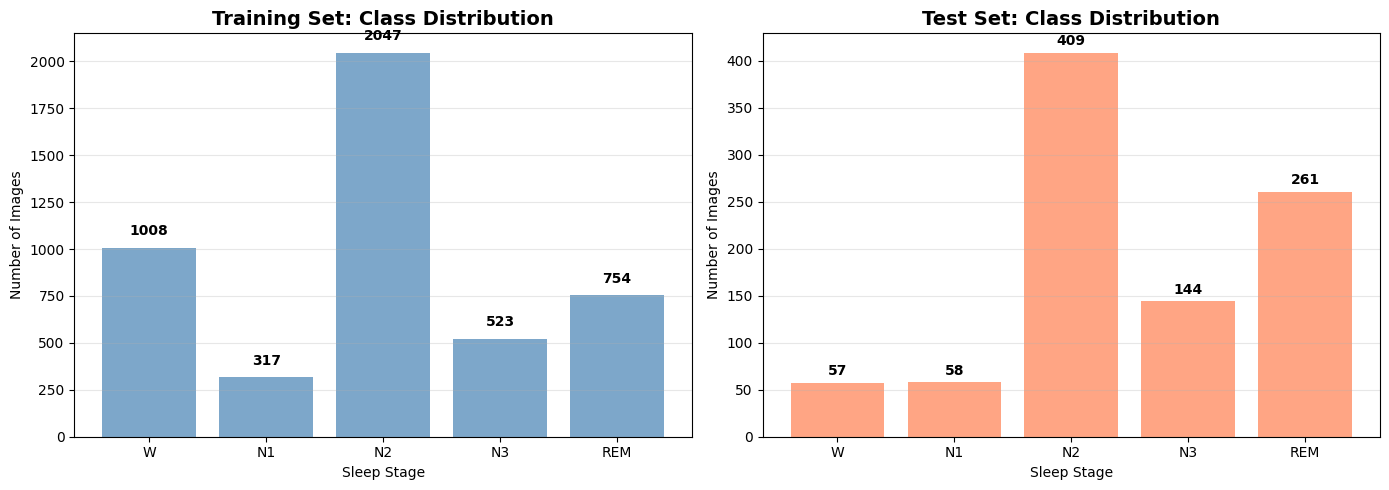


Class imbalance ratio (max/min): 6.46
Significant class imbalance detected - consider using class weights or resampling


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(train_stats['class'], train_stats['num_images'], color='steelblue', alpha=0.7)
axes[0].set_title('Training Set: Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sleep Stage')
axes[0].set_ylabel('Number of Images')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_stats['num_images']):
    axes[0].text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

axes[1].bar(test_stats['class'], test_stats['num_images'], color='coral', alpha=0.7)
axes[1].set_title('Test Set: Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sleep Stage')
axes[1].set_ylabel('Number of Images')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_stats['num_images']):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = train_stats['num_images'].max() / train_stats['num_images'].min()
print(f"\nClass imbalance ratio (max/min): {imbalance_ratio:.2f}")
if imbalance_ratio > 3:
    print("Significant class imbalance detected - consider using class weights or resampling")

In [8]:
def get_patient_epoch_distribution(data_path, classes):
    patient_epoch_count = {}

    for cls in classes:
        class_path = os.path.join(data_path, cls)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.endswith('.png')]

        for f in files:
            patient_id = f.split('_')[0]
            if patient_id not in patient_epoch_count:
                patient_epoch_count[patient_id] = 0
            patient_epoch_count[patient_id] += 1

    return patient_epoch_count

train_patient_dist = get_patient_epoch_distribution(TRAIN_PATH, CLASSES)
test_patient_dist = get_patient_epoch_distribution(TEST_PATH, CLASSES)

print("PATIENT EPOCH DISTRIBUTION (TRAIN)")
for patient, count in sorted(train_patient_dist.items()):
    print(f"{patient}: {count} epochs")

print(f"\nAverage epochs per patient (train): {np.mean(list(train_patient_dist.values())):.1f}")
print(f"Min epochs per patient (train): {np.min(list(train_patient_dist.values()))}")
print(f"Max epochs per patient (train): {np.max(list(train_patient_dist.values()))}")

print("\nPATIENT EPOCH DISTRIBUTION (TEST)")
for patient, count in sorted(test_patient_dist.items()):
    print(f"{patient}: {count} epochs")

PATIENT EPOCH DISTRIBUTION (TRAIN)
Sub003: 986 epochs
Sub004: 620 epochs
Sub008: 969 epochs
Sub010: 1063 epochs
Sub011: 1011 epochs

Average epochs per patient (train): 929.8
Min epochs per patient (train): 620
Max epochs per patient (train): 1063

PATIENT EPOCH DISTRIBUTION (TEST)
Sub015: 929 epochs


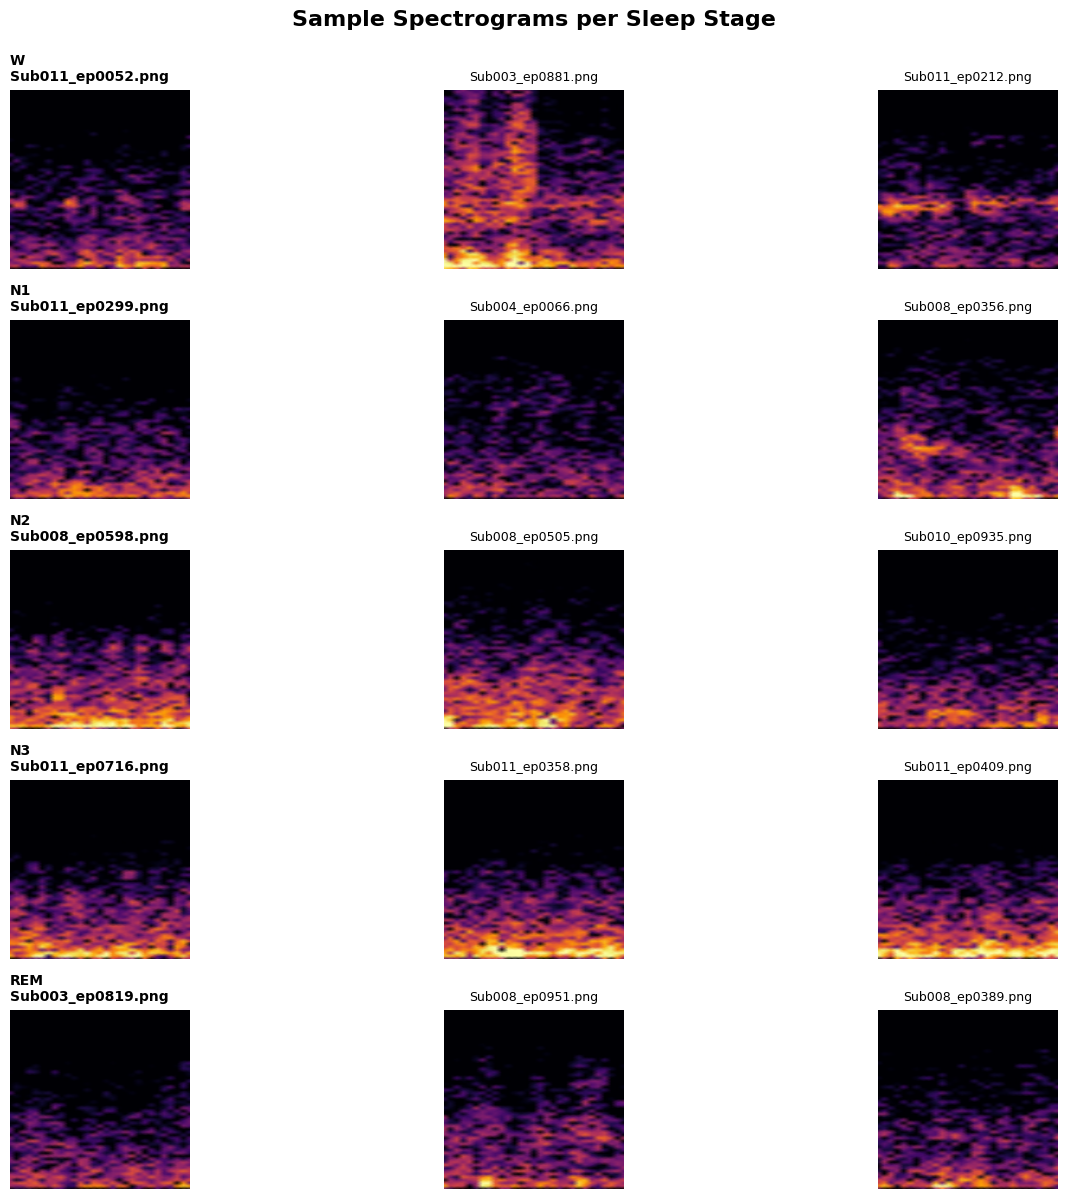

In [9]:
def visualize_samples(data_path, classes, num_samples=3):
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 12))

    for i, cls in enumerate(classes):
        class_path = os.path.join(data_path, cls)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.endswith('.png')]
        selected_files = np.random.choice(files, min(num_samples, len(files)), replace=False)

        for j, file in enumerate(selected_files):
            img_path = os.path.join(class_path, file)
            img = Image.open(img_path)

            axes[i, j].imshow(img)
            axes[i, j].axis('off')

            if j == 0:
                axes[i, j].set_title(f'{cls}\n{file}', fontsize=10, fontweight='bold', loc='left')
            else:
                axes[i, j].set_title(file, fontsize=9)

    plt.suptitle('Sample Spectrograms per Sleep Stage', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

visualize_samples(TRAIN_PATH, CLASSES, num_samples=3)

In [10]:
def analyze_image_properties(data_path, classes, num_samples=10):
    properties = {
        'shapes': [],
        'dtypes': [],
        'mean_values': [],
        'std_values': []
    }

    for cls in classes:
        class_path = os.path.join(data_path, cls)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.endswith('.png')]
        selected_files = np.random.choice(files, min(num_samples, len(files)), replace=False)

        for file in selected_files:
            img_path = os.path.join(class_path, file)
            img = np.array(Image.open(img_path))

            properties['shapes'].append(img.shape)
            properties['dtypes'].append(img.dtype)
            properties['mean_values'].append(img.mean())
            properties['std_values'].append(img.std())

    return properties

props = analyze_image_properties(TRAIN_PATH, CLASSES, num_samples=10)

print(f"Unique shapes: {set(props['shapes'])}")
print(f"Unique dtypes: {set(props['dtypes'])}")
print(f"Mean pixel value (avg): {np.mean(props['mean_values']):.2f}")
print(f"Std pixel value (avg): {np.mean(props['std_values']):.2f}")
print(f"Min mean across images: {np.min(props['mean_values']):.2f}")
print(f"Max mean across images: {np.max(props['mean_values']):.2f}")

Unique shapes: {(300, 300, 4)}
Unique dtypes: {dtype('uint8')}
Mean pixel value (avg): 93.52
Std pixel value (avg): 103.86
Min mean across images: 83.24
Max mean across images: 111.30


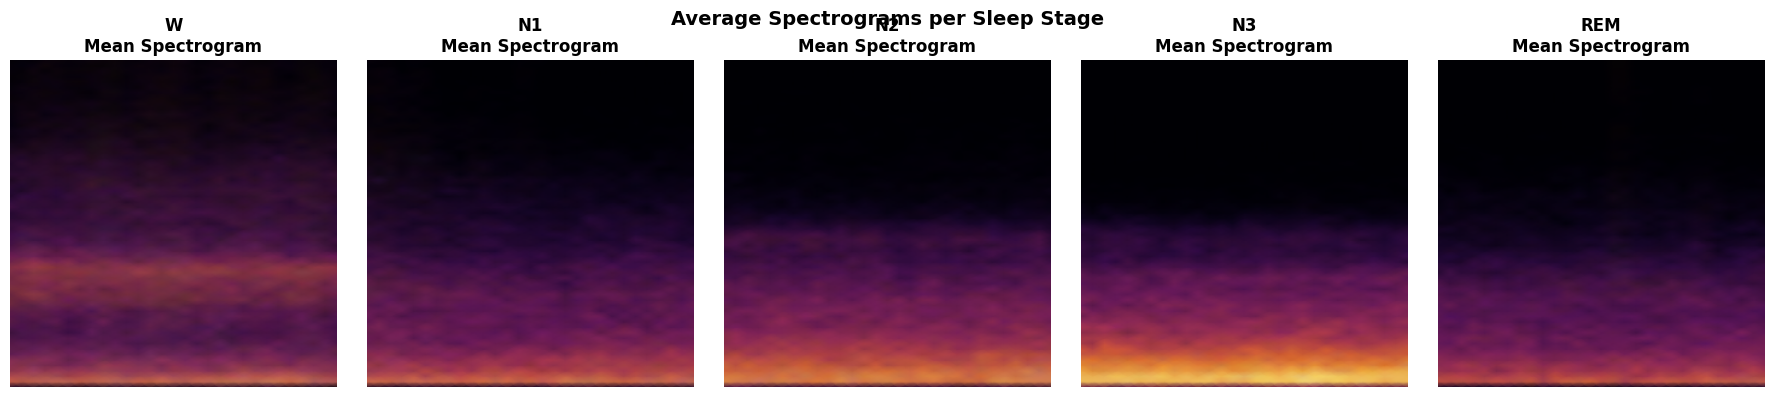

In [11]:
def compute_mean_spectrogram(data_path, classes, num_samples=50):
    mean_spectrograms = {}

    for cls in classes:
        class_path = os.path.join(data_path, cls)
        if not os.path.exists(class_path):
            continue

        files = [f for f in os.listdir(class_path) if f.endswith('.png')]
        selected_files = np.random.choice(files, min(num_samples, len(files)), replace=False)

        images = []
        for file in selected_files:
            img_path = os.path.join(class_path, file)
            img = np.array(Image.open(img_path)).astype(np.float32)
            images.append(img)

        mean_spectrograms[cls] = np.mean(images, axis=0)

    return mean_spectrograms

mean_specs = compute_mean_spectrogram(TRAIN_PATH, CLASSES, num_samples=50)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 4))

for i, cls in enumerate(CLASSES):
    if cls in mean_specs:
        axes[i].imshow(mean_specs[cls].astype(np.uint8))
        axes[i].set_title(f'{cls}\nMean Spectrogram', fontweight='bold')
        axes[i].axis('off')

plt.suptitle('Average Spectrograms per Sleep Stage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
print(f"   Total training images: {train_stats['num_images'].sum()}")
print(f"   Total test images: {test_stats['num_images'].sum()}")
print(f"   Number of classes: {len(CLASSES)}")
print(f"   Classes: {CLASSES}")

print(f"   Unique patients in train: {len(set.union(*train_patient_ids))}")
print(f"   Unique patients in test: {len(set.union(*test_patient_ids))}")
print(f"   Patient leakage: {'No' if len(train_patients.intersection(test_patients)) == 0 else 'Yes'}")

print(train_stats[['class', 'num_images']].to_string(index=False))
imb_ratio = train_stats['num_images'].max() / train_stats['num_images'].min()
print(f"   Imbalance ratio: {imb_ratio:.2f}")

print(f"   Shape: {list(set(props['shapes']))[0]}")
print(f"   Dtype: {list(set(props['dtypes']))[0]}")
print(f"   Pixel value range: ~0-255")

if imb_ratio > 3:
    print("- Use class weights due to imbalance")
else:
    print("- Class balance is acceptable")

   Total training images: 4649
   Total test images: 929
   Number of classes: 5
   Classes: ['W', 'N1', 'N2', 'N3', 'REM']
   Unique patients in train: 5
   Unique patients in test: 1
   Patient leakage: No
class  num_images
    W        1008
   N1         317
   N2        2047
   N3         523
  REM         754
   Imbalance ratio: 6.46
   Shape: (300, 300, 4)
   Dtype: uint8
   Pixel value range: ~0-255
- Use class weights due to imbalance


# Dataset handling

In [13]:
class SleepSpectrogramDataset(Dataset):
    def __init__(self, data_path, classes, transform=None):
        self.data_path = data_path
        self.classes = classes
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

        self.samples = []
        for cls in classes:
            class_path = os.path.join(data_path, cls)
            if not os.path.exists(class_path):
                continue

            files = [f for f in os.listdir(class_path) if f.endswith('.png')]
            for f in files:
                self.samples.append((os.path.join(class_path, f), self.class_to_idx[cls]))

        print(f"Loaded {len(self.samples)} samples from {data_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = Image.open(img_path)

        if img.mode == 'RGBA':
            img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

# Augmentation (ImageNet not flip)

In [14]:
class SpecAugment:
    def __init__(self, freq_mask_param=8, time_mask_param=5, num_freq_masks=2, num_time_masks=2, p=0.5):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.num_freq_masks = num_freq_masks
        self.num_time_masks = num_time_masks
        self.p = p

    def __call__(self, img):
        import torch

        if torch.rand(1).item() > self.p:
            return img

        C, H, W = img.shape
        img = img.clone()

        for _ in range(self.num_freq_masks):
            f = torch.randint(1, self.freq_mask_param + 1, (1,)).item()
            f0 = torch.randint(0, max(1, H - f + 1), (1,)).item()
            img[:, f0:f0+f, :] = 0

        for _ in range(self.num_time_masks):
            t = torch.randint(1, self.time_mask_param + 1, (1,)).item()
            t0 = torch.randint(0, max(1, W - t + 1), (1,)).item()
            img[:, :, t0:t0+t] = 0

        return img

spec_augment = SpecAugment(freq_mask_param=8, time_mask_param=5, num_freq_masks=2, num_time_masks=2, p=0.5)
print("Parameters: freq_mask=8Hz, time_mask=5 steps, 2 masks each, p=0.5")

Parameters: freq_mask=8Hz, time_mask=5 steps, 2 masks each, p=0.5


In [15]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    SpecAugment(freq_mask_param=8, time_mask_param=5, num_freq_masks=2, num_time_masks=2, p=0.5)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Data loader

In [16]:
train_dataset = SleepSpectrogramDataset(TRAIN_PATH, CLASSES, transform=train_transform)
test_dataset = SleepSpectrogramDataset(TEST_PATH, CLASSES, transform=test_transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

class_counts = train_stats['num_images'].values
total_samples = sum(class_counts)
class_weights = torch.FloatTensor([total_samples / (len(class_counts) * count) for count in class_counts])
class_weights = class_weights.to(device)

print(f"\nClass weights (to handle imbalance):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {class_weights[i]:.3f}")

Loaded 4649 samples from /content/data/sleep_spectrogram_dataset
Loaded 929 samples from /content/data/test_set_unseen_sub015
Train batches: 146
Test batches: 30

Class weights (to handle imbalance):
  W: 0.922
  N1: 2.933
  N2: 0.454
  N3: 1.778
  REM: 1.233


# Model

## Custom CNN

In [17]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_custom = CustomCNN(num_classes=len(CLASSES))
total_params = sum(p.numel() for p in model_custom.parameters())
trainable_params = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)

print(f"Custom CNN Architecture:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: ~{total_params * 4 / (1024**2):.2f} MB")

Custom CNN Architecture:
Total parameters: 1,703,173
Trainable parameters: 1,703,173
Model size: ~6.50 MB


## Pretrained models

In [18]:
def create_resnet18(num_classes=5, pretrained=True):
    model = models.resnet18(pretrained=pretrained)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

def create_efficientnet_b0(num_classes=5, pretrained=True):
    model = models.efficientnet_b0(pretrained=pretrained)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    return model

def create_mobilenet_v2(num_classes=5, pretrained=True):
    model = models.mobilenet_v2(pretrained=pretrained)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    return model

model_resnet = create_resnet18(num_classes=len(CLASSES), pretrained=True)
model_efficientnet = create_efficientnet_b0(num_classes=len(CLASSES), pretrained=True)
model_mobilenet = create_mobilenet_v2(num_classes=len(CLASSES), pretrained=True)

for name, model in [("ResNet18", model_resnet), ("EfficientNet-B0", model_efficientnet), ("MobileNetV2", model_mobilenet)]:
    total = sum(p.numel() for p in model.parameters())
    print(f"{name}: {total:,} parameters")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 43.4MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 101MB/s]

ResNet18: 11,179,077 parameters
EfficientNet-B0: 4,013,953 parameters
MobileNetV2: 2,230,277 parameters


# Train + val

In [19]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'loss': running_loss/len(pbar), 'acc': 100.*correct/total})

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def validate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': running_loss/len(pbar), 'acc': 100.*correct/total})

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

print("Training and validation functions defined")

Training and validation functions defined


In [20]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.val_loss_min = float('inf')

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [21]:
def train_model_with_early_stopping(model, model_name, train_loader, test_loader, criterion, optimizer, scheduler, num_epochs, device, patience=7):

    early_stopping = EarlyStopping(patience=patience, min_delta=0.001, verbose=True)

    best_acc = 0.0
    best_epoch = 0
    train_history = {'loss': [], 'acc': []}
    val_history = {'loss': [], 'acc': []}

    print(f"\nTraining {model_name}")
    print("="*60)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_preds, val_labels = validate(model, test_loader, criterion, device)

        train_history['loss'].append(train_loss)
        train_history['acc'].append(train_acc)
        val_history['loss'].append(val_loss)
        val_history['acc'].append(val_acc)

        if scheduler:
            scheduler.step()

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'/content/{model_name}_best.pth')
            print(f"Best model saved! Val Acc: {best_acc:.2f}%")

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    print("\n" + "="*60)
    print(f"Training completed for {model_name}")
    print(f"Best Val Acc: {best_acc:.2f}% at epoch {best_epoch}")
    if early_stopping.early_stop:
        print(f"Stopped early after {epoch+1} epochs (patience={patience})")

    return train_history, val_history, best_acc

print("Training loop with early stopping defined")

Training loop with early stopping defined


In [25]:
def train_model_differential_lr(model, model_name, train_loader, test_loader, criterion,
                                backbone_lr, head_lr, num_epochs, device,
                                freeze_epochs=3, patience=10, is_pretrained=True):

    if is_pretrained:
        if hasattr(model, 'fc'):
            backbone_params = [p for n, p in model.named_parameters() if 'fc' not in n]
            head_params = [p for n, p in model.named_parameters() if 'fc' in n]
        elif hasattr(model, 'classifier'):
            backbone_params = [p for n, p in model.named_parameters() if 'classifier' not in n]
            head_params = [p for n, p in model.named_parameters() if 'classifier' in n]
        else:
            backbone_params = []
            head_params = list(model.parameters())

        for param in backbone_params:
            param.requires_grad = False

        optimizer = optim.Adam([
            {'params': head_params, 'lr': head_lr}
        ])

        print(f"Phase 1: Freezing backbone, training head with LR={head_lr}")
    else:
        optimizer = optim.Adam(model.parameters(), lr=head_lr)
        print(f"Training from scratch with LR={head_lr}")

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    early_stopping = EarlyStopping(patience=patience, min_delta=0.001, verbose=True)

    best_acc = 0.0
    best_epoch = 0
    train_history = {'loss': [], 'acc': []}
    val_history = {'loss': [], 'acc': []}
    phase = 1

    print(f"\nTraining {model_name}")
    print("="*60)

    for epoch in range(num_epochs):
        if is_pretrained and epoch == freeze_epochs and phase == 1:
            print(f"\nPhase 2: Unfreezing backbone")
            for param in backbone_params:
                param.requires_grad = True

            optimizer = optim.Adam([
                {'params': backbone_params, 'lr': backbone_lr},
                {'params': head_params, 'lr': head_lr}
            ])
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
            print(f"Backbone LR={backbone_lr}, Head LR={head_lr}")
            phase = 2

        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_preds, val_labels = validate(model, test_loader, criterion, device)

        train_history['loss'].append(train_loss)
        train_history['acc'].append(train_acc)
        val_history['loss'].append(val_loss)
        val_history['acc'].append(val_acc)

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'/content/{model_name}_best.pth')
            print(f"Best model saved! Val Acc: {best_acc:.2f}%")

        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

    print("\n" + "="*60)
    print(f"Training completed for {model_name}")
    print(f"Best Val Acc: {best_acc:.2f}% at epoch {best_epoch}")
    if early_stopping.early_stop:
        print(f"Stopped early after {epoch+1} epochs (patience={patience})")

    return train_history, val_history, best_acc

print("Training function with differential LR and ReduceLROnPlateau defined")

Training function with differential LR and ReduceLROnPlateau defined


# Eval

In [23]:
def evaluate_model(model, test_loader, device, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Evaluating'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print(f"\n{'='*60}")
    print(f"Evaluation Results: {model_name}")
    print(f"{'='*60}\n")

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    print("\nConfusion Matrix:")
    print(cm)

    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f"\nCohen's Kappa Score: {kappa:.4f}")

    accuracy = (all_preds == all_labels).mean() * 100
    print(f"Overall Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'/content/{model_name}_confusion_matrix.png', dpi=150)
    plt.show()

    return {
        'predictions': all_preds,
        'labels': all_labels,
        'accuracy': accuracy,
        'kappa': kappa,
        'confusion_matrix': cm
    }

print("Evaluation function defined")

Evaluation function defined


# Start

### Custom

In [26]:
NUM_EPOCHS = 3000
LEARNING_RATE = 0.001
PATIENCE = 7

model_custom = CustomCNN(num_classes=len(CLASSES)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_hist_custom, val_hist_custom, best_acc_custom = train_model_differential_lr(
    model=model_custom,
    model_name="CustomCNN",
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    backbone_lr=0.001,
    head_lr=0.001,
    num_epochs=NUM_EPOCHS,
    device=device,
    freeze_epochs=0,
    patience=PATIENCE,
    is_pretrained=False
)

Training from scratch with LR=0.001

Training CustomCNN

Epoch 1/3000


Validation: 100%|██████████| 30/30 [00:05<00:00,  5.50it/s, loss=1.06, acc=51.3]


Train Loss: 0.9875, Train Acc: 55.35%
Val Loss: 1.0613, Val Acc: 51.35%
Best model saved! Val Acc: 51.35%

Epoch 2/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  7.14it/s, loss=1.01, acc=60.6]


Train Loss: 0.7978, Train Acc: 64.19%
Val Loss: 1.0130, Val Acc: 60.60%
Best model saved! Val Acc: 60.60%

Epoch 3/3000


...

Train Loss: 0.5606, Train Acc: 77.41%
Val Loss: 0.4612, Val Acc: 83.75%
EarlyStopping counter: 5 out of 7

Epoch 16/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.90it/s, loss=0.453, acc=84.1]


Train Loss: 0.5558, Train Acc: 77.63%
Val Loss: 0.4528, Val Acc: 84.07%
EarlyStopping counter: 6 out of 7

Epoch 17/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.78it/s, loss=0.455, acc=83.9]

Train Loss: 0.5724, Train Acc: 78.04%
Val Loss: 0.4547, Val Acc: 83.85%
EarlyStopping counter: 7 out of 7

Early stopping triggered at epoch 17

Training completed for CustomCNN
Best Val Acc: 85.04% at epoch 10
Stopped early after 17 epochs (patience=7)


### Resnet18

In [27]:
NUM_EPOCHS = 3000
BACKBONE_LR = 0.00001
HEAD_LR = 0.001
FREEZE_EPOCHS = 3
PATIENCE = 10

model_resnet = create_resnet18(num_classes=len(CLASSES), pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_hist_resnet, val_hist_resnet, best_acc_resnet = train_model_differential_lr(
    model=model_resnet,
    model_name="ResNet18_v2",
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    backbone_lr=BACKBONE_LR,
    head_lr=HEAD_LR,
    num_epochs=NUM_EPOCHS,
    device=device,
    freeze_epochs=FREEZE_EPOCHS,
    patience=PATIENCE,
    is_pretrained=True
)

Phase 1: Freezing backbone, training head with LR=0.001

Training ResNet18_v2

Epoch 1/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.71it/s, loss=1.16, acc=48]


Train Loss: 1.3184, Train Acc: 45.13%
Val Loss: 1.1644, Val Acc: 48.01%
Best model saved! Val Acc: 48.01%

Epoch 2/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.98it/s, loss=0.796, acc=74.5]


Train Loss: 1.0561, Train Acc: 56.23%
Val Loss: 0.7964, Val Acc: 74.49%
Best model saved! Val Acc: 74.49%

Epoch 3/3000


...

Train Loss: 0.3867, Train Acc: 84.53%
Val Loss: 0.4111, Val Acc: 84.82%
EarlyStopping counter: 8 out of 10

Epoch 18/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.38it/s, loss=0.439, acc=83.9]


Train Loss: 0.4015, Train Acc: 84.45%
Val Loss: 0.4391, Val Acc: 83.85%
EarlyStopping counter: 9 out of 10

Epoch 19/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  7.10it/s, loss=0.427, acc=84.5]

Train Loss: 0.3933, Train Acc: 84.45%
Val Loss: 0.4273, Val Acc: 84.50%
EarlyStopping counter: 10 out of 10

Early stopping triggered at epoch 19

Training completed for ResNet18_v2
Best Val Acc: 86.33% at epoch 9
Stopped early after 19 epochs (patience=10)


### EfficientNet-B0

In [28]:
NUM_EPOCHS = 3000
BACKBONE_LR = 0.00001
HEAD_LR = 0.001
FREEZE_EPOCHS = 3
PATIENCE = 10

model_efficientnet = create_efficientnet_b0(num_classes=len(CLASSES), pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_hist_effnet, val_hist_effnet, best_acc_effnet = train_model_differential_lr(
    model=model_efficientnet,
    model_name="EfficientNet-B0_v2",
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    backbone_lr=BACKBONE_LR,
    head_lr=HEAD_LR,
    num_epochs=NUM_EPOCHS,
    device=device,
    freeze_epochs=FREEZE_EPOCHS,
    patience=PATIENCE,
    is_pretrained=True
)

Phase 1: Freezing backbone, training head with LR=0.001

Training EfficientNet-B0_v2

Epoch 1/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.73it/s, loss=1.16, acc=44]


Train Loss: 1.2596, Train Acc: 52.01%
Val Loss: 1.1640, Val Acc: 44.03%
Best model saved! Val Acc: 44.03%

Epoch 2/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.79it/s, loss=1.02, acc=57.3]


Train Loss: 1.0217, Train Acc: 60.14%
Val Loss: 1.0205, Val Acc: 57.27%
Best model saved! Val Acc: 57.27%

Epoch 3/3000


...

Train Loss: 0.5270, Train Acc: 80.04%
Val Loss: 0.5071, Val Acc: 81.59%
EarlyStopping counter: 8 out of 10

Epoch 20/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.38it/s, loss=0.465, acc=83.6]


Train Loss: 0.5234, Train Acc: 78.98%
Val Loss: 0.4648, Val Acc: 83.64%
EarlyStopping counter: 9 out of 10

Epoch 21/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.35it/s, loss=0.477, acc=83.2]

Train Loss: 0.5343, Train Acc: 78.88%
Val Loss: 0.4770, Val Acc: 83.21%
EarlyStopping counter: 10 out of 10

Early stopping triggered at epoch 21

Training completed for EfficientNet-B0_v2
Best Val Acc: 84.39% at epoch 11
Stopped early after 21 epochs (patience=10)


### MobileNet

In [29]:
NUM_EPOCHS = 3000
BACKBONE_LR = 0.00001
HEAD_LR = 0.001
FREEZE_EPOCHS = 3
PATIENCE = 10

model_mobilenet = create_mobilenet_v2(num_classes=len(CLASSES), pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

train_hist_mobile, val_hist_mobile, best_acc_mobile = train_model_differential_lr(
    model=model_mobilenet,
    model_name="MobileNetV2_v2",
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    backbone_lr=BACKBONE_LR,
    head_lr=HEAD_LR,
    num_epochs=NUM_EPOCHS,
    device=device,
    freeze_epochs=FREEZE_EPOCHS,
    patience=PATIENCE,
    is_pretrained=True
)

Phase 1: Freezing backbone, training head with LR=0.001

Training MobileNetV2_v2

Epoch 1/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.65it/s, loss=1.04, acc=61.9]


Train Loss: 1.3069, Train Acc: 42.07%
Val Loss: 1.0351, Val Acc: 61.89%
Best model saved! Val Acc: 61.89%

Epoch 2/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  6.76it/s, loss=0.887, acc=72.6]


Train Loss: 1.0891, Train Acc: 53.90%
Val Loss: 0.8869, Val Acc: 72.55%
Best model saved! Val Acc: 72.55%

Epoch 3/3000


...

Train Loss: 0.4908, Train Acc: 80.62%
Val Loss: 0.4214, Val Acc: 86.11%
Best model saved! Val Acc: 86.11%
EarlyStopping counter: 8 out of 10

Epoch 21/3000


Validation: 100%|██████████| 30/30 [00:05<00:00,  5.58it/s, loss=0.423, acc=85.3]


Train Loss: 0.5012, Train Acc: 81.11%
Val Loss: 0.4226, Val Acc: 85.25%
EarlyStopping counter: 9 out of 10

Epoch 22/3000


Validation: 100%|██████████| 30/30 [00:04<00:00,  7.03it/s, loss=0.452, acc=85.3]

Train Loss: 0.5015, Train Acc: 80.99%
Val Loss: 0.4518, Val Acc: 85.25%
EarlyStopping counter: 10 out of 10

Early stopping triggered at epoch 22

Training completed for MobileNetV2_v2
Best Val Acc: 86.11% at epoch 20
Stopped early after 22 epochs (patience=10)


## Evaluate

Evaluating: 100%|██████████| 30/30 [00:05<00:00,  5.48it/s]



Evaluation Results: CustomCNN

Classification Report:
              precision    recall  f1-score   support

           W     0.7536    0.9123    0.8254        57
          N1     0.4091    0.4655    0.4355        58
          N2     0.9465    0.8655    0.9042       409
          N3     0.9580    0.9514    0.9547       144
         REM     0.7942    0.8429    0.8178       261

    accuracy                         0.8504       929
   macro avg     0.7723    0.8075    0.7875       929
weighted avg     0.8601    0.8504    0.8537       929


Confusion Matrix:
[[ 52   1   3   1   0]
 [  6  27   2   0  23]
 [  4  12 354   5  34]
 [  0   0   7 137   0]
 [  7  26   8   0 220]]

Cohen's Kappa Score: 0.7881
Overall Accuracy: 85.04%


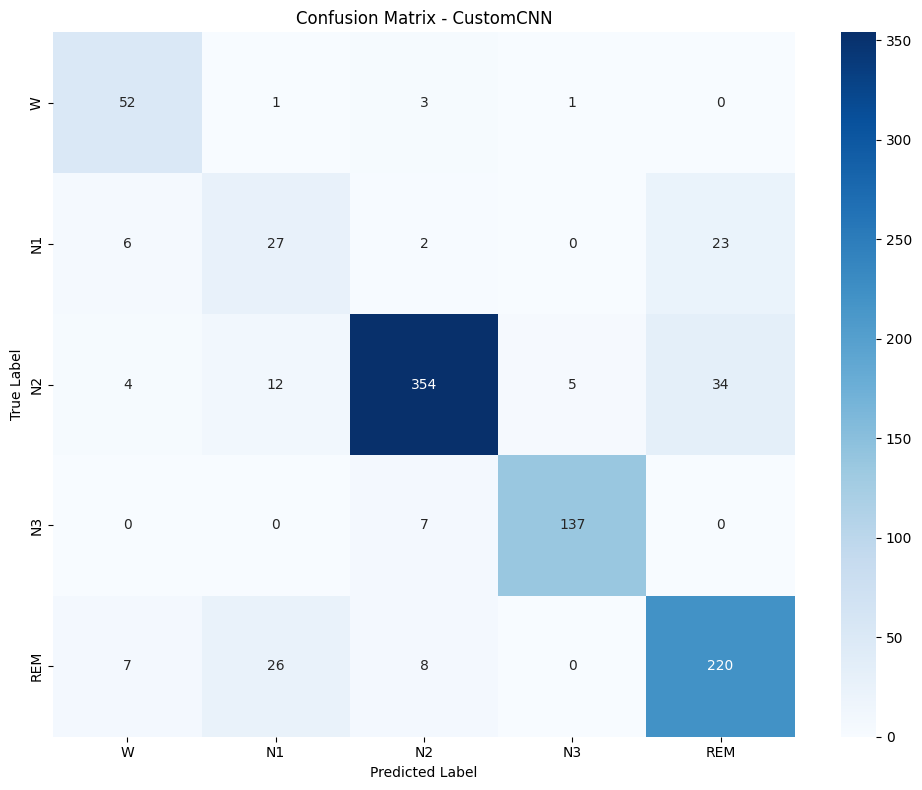

Evaluating: 100%|██████████| 30/30 [00:05<00:00,  5.53it/s]



Evaluation Results: ResNet18

Classification Report:
              precision    recall  f1-score   support

           W     0.8226    0.8947    0.8571        57
          N1     0.3804    0.6034    0.4667        58
          N2     0.9721    0.8509    0.9074       409
          N3     0.9329    0.9653    0.9488       144
         REM     0.8545    0.8774    0.8658       261

    accuracy                         0.8633       929
   macro avg     0.7925    0.8383    0.8092       929
weighted avg     0.8868    0.8633    0.8715       929


Confusion Matrix:
[[ 51   3   0   2   1]
 [  6  35   0   0  17]
 [  2  31 348   7  21]
 [  0   0   5 139   0]
 [  3  23   5   1 229]]

Cohen's Kappa Score: 0.8086
Overall Accuracy: 86.33%


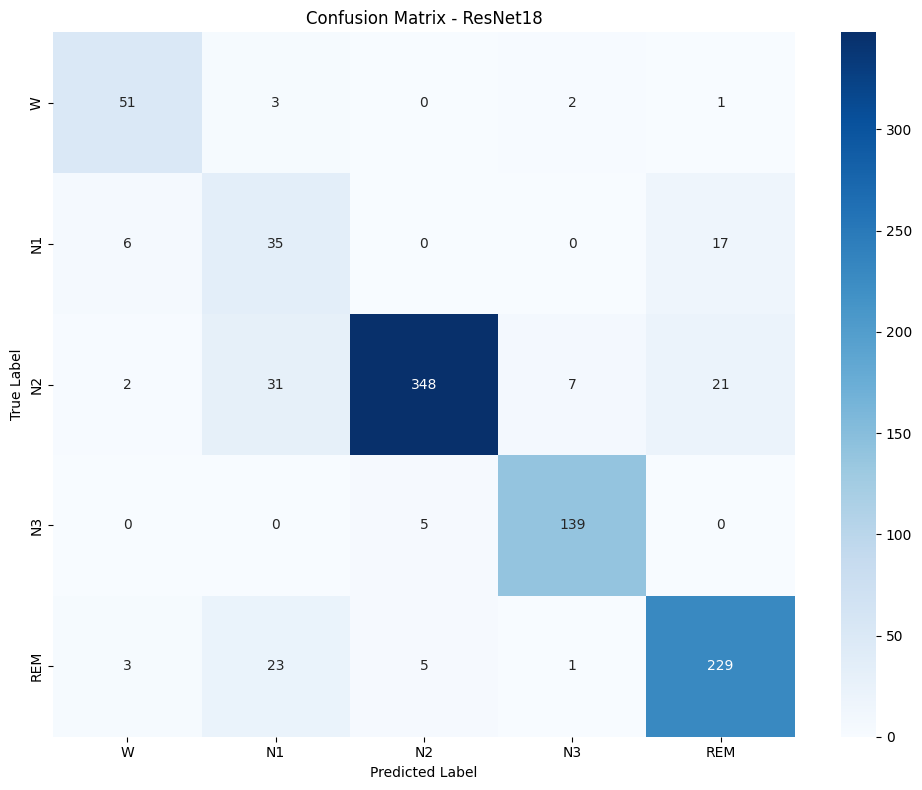

Evaluating: 100%|██████████| 30/30 [00:04<00:00,  6.56it/s]



Evaluation Results: EfficientNet-B0

Classification Report:
              precision    recall  f1-score   support

           W     0.6067    0.9474    0.7397        57
          N1     0.3714    0.2241    0.2796        58
          N2     0.9489    0.8631    0.9040       409
          N3     0.9441    0.9375    0.9408       144
         REM     0.7897    0.8774    0.8312       261

    accuracy                         0.8439       929
   macro avg     0.7322    0.7699    0.7390       929
weighted avg     0.8464    0.8439    0.8402       929


Confusion Matrix:
[[ 54   2   0   0   1]
 [ 14  13   2   0  29]
 [  9   8 353   8  31]
 [  0   0   9 135   0]
 [ 12  12   8   0 229]]

Cohen's Kappa Score: 0.7783
Overall Accuracy: 84.39%


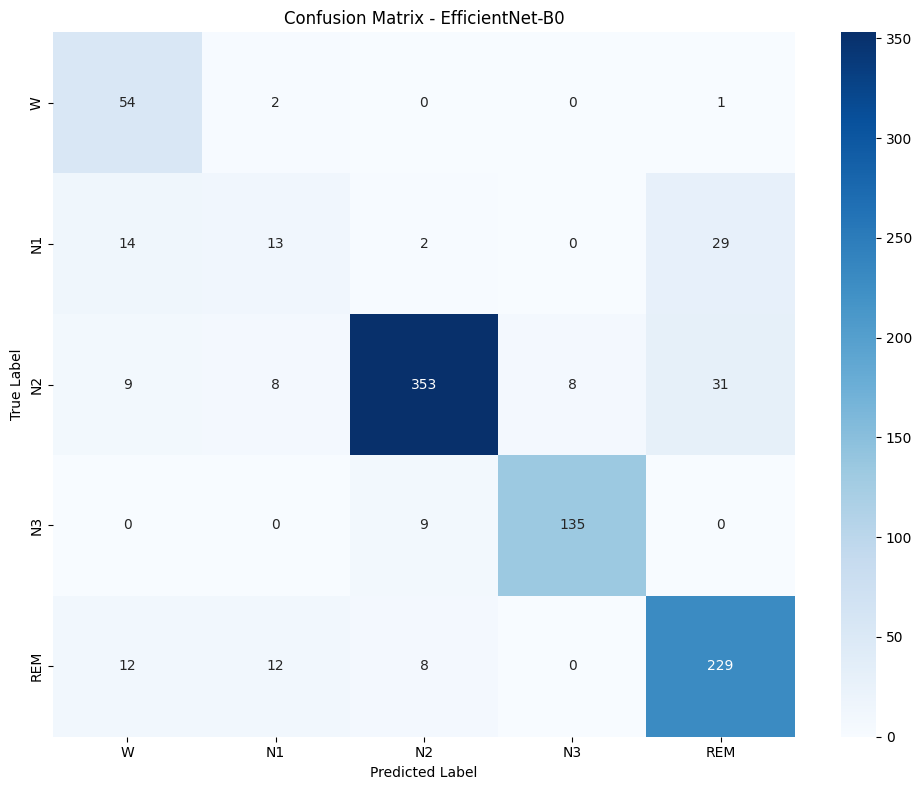

Evaluating: 100%|██████████| 30/30 [00:05<00:00,  5.97it/s]



Evaluation Results: MobileNetV2

Classification Report:
              precision    recall  f1-score   support

           W     0.8182    0.9474    0.8780        57
          N1     0.4127    0.4483    0.4298        58
          N2     0.9412    0.8606    0.8991       409
          N3     0.9559    0.9028    0.9286       144
         REM     0.8207    0.9119    0.8639       261

    accuracy                         0.8611       929
   macro avg     0.7897    0.8142    0.7999       929
weighted avg     0.8691    0.8611    0.8632       929


Confusion Matrix:
[[ 54   2   0   1   0]
 [  7  26   2   0  23]
 [  4  19 352   5  29]
 [  0   0  14 130   0]
 [  1  16   6   0 238]]

Cohen's Kappa Score: 0.8027
Overall Accuracy: 86.11%


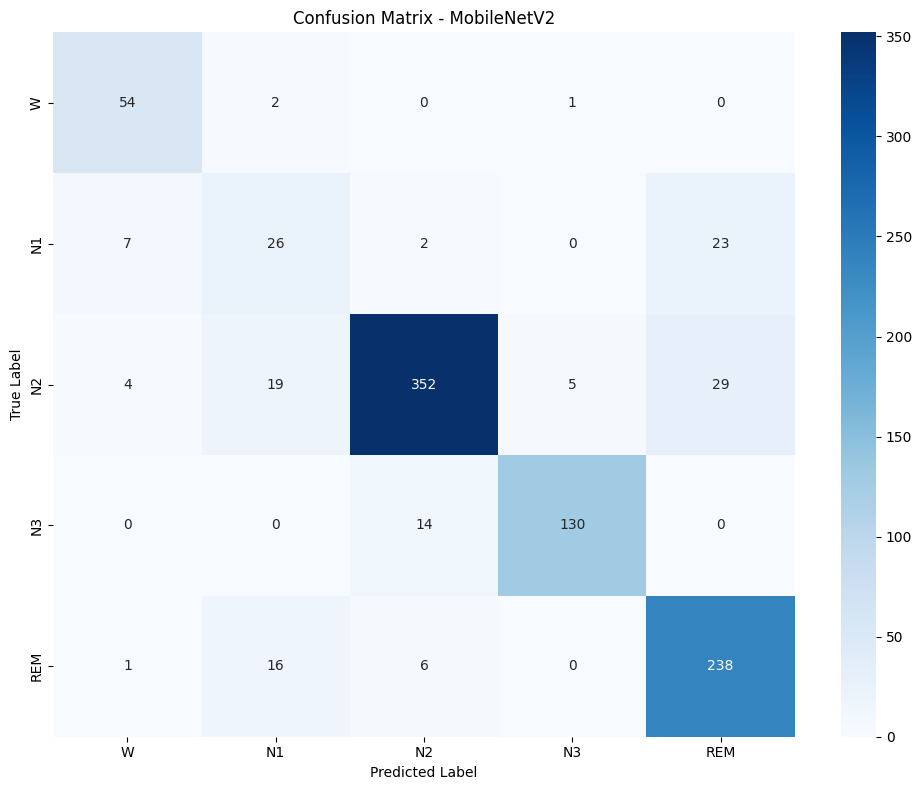

In [31]:
model_custom.load_state_dict(torch.load('/content/CustomCNN_best.pth'))
results_custom = evaluate_model(model_custom, test_loader, device, "CustomCNN")

model_resnet.load_state_dict(torch.load('/content/ResNet18_v2_best.pth'))
results_resnet = evaluate_model(model_resnet, test_loader, device, "ResNet18")

model_efficientnet.load_state_dict(torch.load('/content/EfficientNet-B0_v2_best.pth'))
results_effnet = evaluate_model(model_efficientnet, test_loader, device, "EfficientNet-B0")

model_mobilenet.load_state_dict(torch.load('/content/MobileNetV2_v2_best.pth'))
results_mobile = evaluate_model(model_mobilenet, test_loader, device, "MobileNetV2")


MODEL COMPARISON
          Model  Best Val Acc  Test Acc  Cohen Kappa
      CustomCNN     85.037675 85.037675     0.788110
       ResNet18     86.329386 86.329386     0.808576
EfficientNet-B0     84.391819 84.391819     0.778266
    MobileNetV2     86.114101 86.114101     0.802694


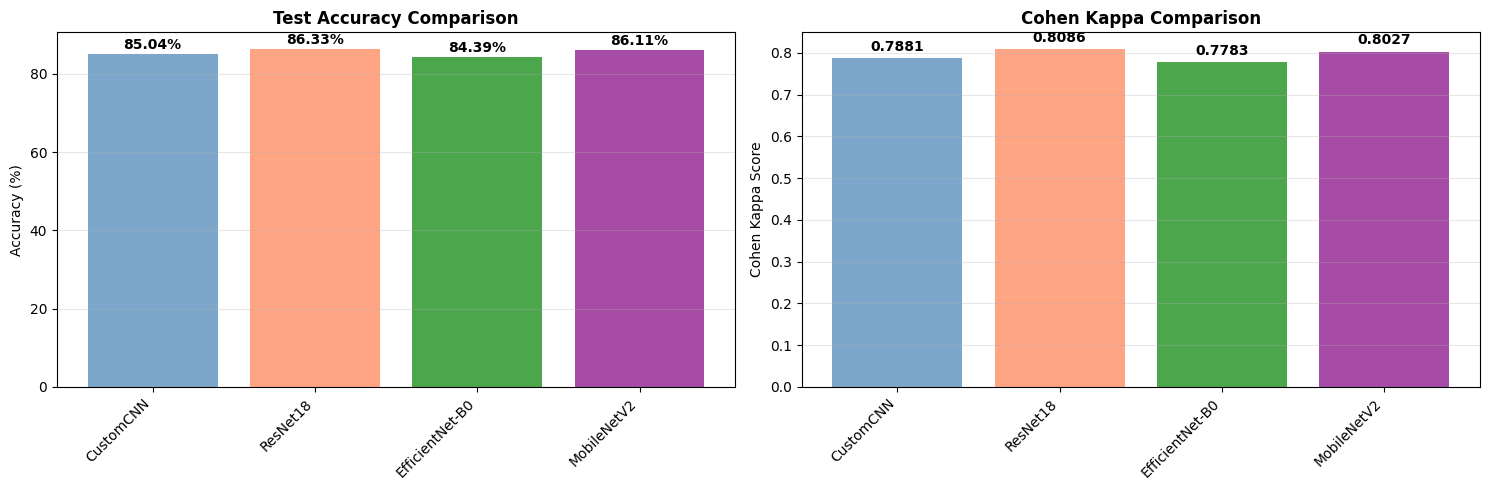


Best performing model: ResNet18
Test Accuracy: 86.33%
Cohen Kappa: 0.8086


In [32]:
comparison_df = pd.DataFrame({
    'Model': ['CustomCNN', 'ResNet18', 'EfficientNet-B0', 'MobileNetV2'],
    'Best Val Acc': [best_acc_custom, best_acc_resnet, best_acc_effnet, best_acc_mobile],
    'Test Acc': [results_custom['accuracy'], results_resnet['accuracy'],
                 results_effnet['accuracy'], results_mobile['accuracy']],
    'Cohen Kappa': [results_custom['kappa'], results_resnet['kappa'],
                    results_effnet['kappa'], results_mobile['kappa']]
})

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_pos = np.arange(len(comparison_df))
axes[0].bar(x_pos, comparison_df['Test Acc'], color=['steelblue', 'coral', 'green', 'purple'], alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Test Acc']):
    axes[0].text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom', fontweight='bold')

axes[1].bar(x_pos, comparison_df['Cohen Kappa'], color=['steelblue', 'coral', 'green', 'purple'], alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].set_ylabel('Cohen Kappa Score')
axes[1].set_title('Cohen Kappa Comparison', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison_df['Cohen Kappa']):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150)
plt.show()

best_model_idx = comparison_df['Test Acc'].idxmax()
best_model = comparison_df.iloc[best_model_idx]
print(f"\nBest performing model: {best_model['Model']}")
print(f"Test Accuracy: {best_model['Test Acc']:.2f}%")
print(f"Cohen Kappa: {best_model['Cohen Kappa']:.4f}")

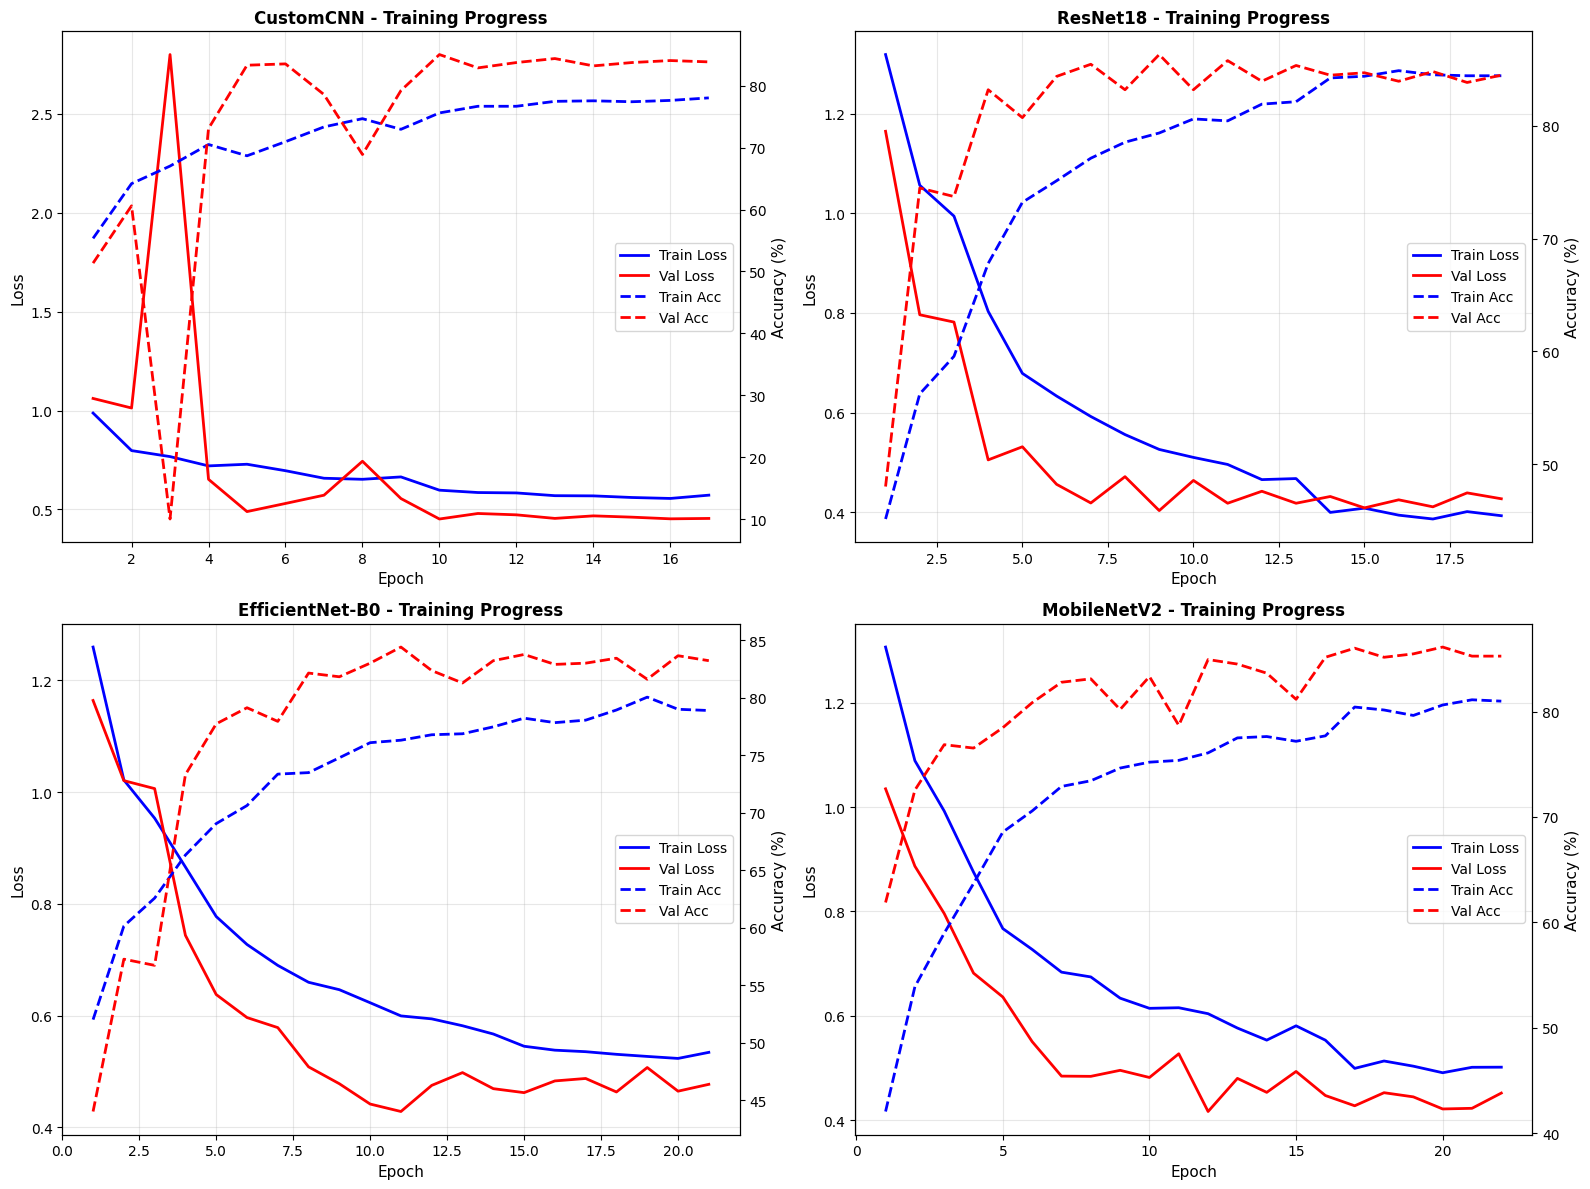

Training curves saved


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('CustomCNN', train_hist_custom, val_hist_custom),
    ('ResNet18', train_hist_resnet, val_hist_resnet),
    ('EfficientNet-B0', train_hist_effnet, val_hist_effnet),
    ('MobileNetV2', train_hist_mobile, val_hist_mobile)
]

for idx, (name, train_hist, val_hist) in enumerate(models_data):
    row = idx // 2
    col = idx % 2

    ax = axes[row, col]
    epochs_range = range(1, len(train_hist['loss']) + 1)

    ax2 = ax.twinx()

    line1 = ax.plot(epochs_range, train_hist['loss'], 'b-', label='Train Loss', linewidth=2)
    line2 = ax.plot(epochs_range, val_hist['loss'], 'r-', label='Val Loss', linewidth=2)
    line3 = ax2.plot(epochs_range, train_hist['acc'], 'b--', label='Train Acc', linewidth=2)
    line4 = ax2.plot(epochs_range, val_hist['acc'], 'r--', label='Val Acc', linewidth=2)

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11, color='black')
    ax2.set_ylabel('Accuracy (%)', fontsize=11, color='black')
    ax.set_title(f'{name} - Training Progress', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='center right')

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

print("Training curves saved")